<a href="https://colab.research.google.com/github/dmora20/EconomiaUAQ/blob/main/data_analyst_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Analyst Assignment

## Introduction

You are working with a US retail customer on a pilot deployment.  They are using technology to track their merchandise throughout their supply chain.  The flow of their supply is:

*   **DC 1:**  Orders are filled and palletized.
*   **Truck:** Pallets travel from the DC 1 to DC 2 via semi-truck.
*   **DC 2:**  Pallets are unloaded, and additional merchandise may be added.  They are then reloaded onto a new truck.
*   **Truck:** Pallets travel from DC 2 to the Store.
*   **Store:** Pallets are unloaded, cases are removed, and stocked, and the empty cases are left behind the building awaiting pickup.

Your job is to dig into the data and find compelling insights to show the value fo the technology and help move the contract from a pilot into a full scaled deployment.



---

## Part 0: Imports

Import necessary packages and

In [ ]:
# YOUR CODE HERE:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Assignment_1.csv')
df.head()

,asset_type,asset_id,tag_id,Site,Zone,device_id,time_est,lat,lng,Temperature_C,Temperature_F
0,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,7F9A8353E973,59:27.0,47.79158,-65.68902,23.0,73.4
1,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,EC5B0499234F,00:23.0,47.79158,-65.68902,23.0,73.4
2,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,7F9A8353E973,01:11.0,47.79158,-65.68902,23.0,73.4
3,tote,2,(01)00850027865010(21)0082T0219,DC 1,dock_doors_DC1,3D8B2BDB8673,47:58.0,47.79158,-65.68902,23.5,74.3
4,tote,2,(01)00850027865010(21)0082T0670,DC 1,dock_doors_DC1,7F9A8353E973,58:55.0,47.79158,-65.68902,23.0,73.4


### Dataset Overview

* Site:  A large space that could contain multiple readers. Ex: DC 1.
* Zone:  Point of interest. These represent areas in which repeaters are installed. These can be thought of as sub-zones.  Ex: Dock Doors.
* Asset ID: The unique ID of the asset.
* Asset Type: The type of thing that is detected (ie tote).
* Device ID: The unique gateway reader ID that detected the device in the zone (there can be multiple in one zone).
* Time est: The time in EST.
* Lon: Longituge
* Lat: Latitude
* Temperature_C / F: Temperature in Celsius, Fahrentheit

## PART 1: Data Overview

### Question 1:

* How many unique cases were we tracking throughout this pilot. (1 pt)
* What are the unique zones we could see (1 pt)
* How many POI's are in each Zone. (2 pts)


In [ ]:
casos_unicos = df['asset_id'].nunique()
print(f"Casos únicos rastreados: {casos_unicos}")

zonas_unicas = df['Zone'].unique()
print(f"Zonas únicas encontradas: {zonas_unicas}")

pois_por_zona = df.groupby('Zone')['device_id'].nunique()
print("\nNúmero de POI's (Dispositivos) por Zona:")
print(pois_por_zona)

Casos únicos rastreados: 18
Zonas únicas encontradas: ['dock_doors_DC1' 'dock_doors_DC2' 'Forklift3_DC1' 'pallet_assembly_DC1'
 'PhoneKit1Bridge' 'PhoneKit2Bridge' 'PhoneKit2GW' 'point_of_sale_Store'
 'receiving_Store' 'staging_DC1' 'staging_DC2' 'store_back_Store'
 'store_front_Store' 'Forklift1_DC1' 'PhoneKit1GW']

Número de POI's (Dispositivos) por Zona:
Zone
Forklift1_DC1          1
Forklift3_DC1          1
PhoneKit1Bridge        1
PhoneKit1GW            1
PhoneKit2Bridge        1
PhoneKit2GW            1
dock_doors_DC1         4
dock_doors_DC2         3
pallet_assembly_DC1    2
point_of_sale_Store    2
receiving_Store        3
staging_DC1            5
staging_DC2            4
store_back_Store       3
store_front_Store      6
Name: device_id, dtype: int64


### Question 2:

* What is the temperature range we see?  (1pt)
* Where is temperature the highest and lowest (1pt)

In [ ]:
temp_col = 'Temperature_C'

# 1. ¿Cuál es el rango de temperatura? (Máxima y Mínima)
# Usamos .max() y .min() para encontrar los extremos
temp_max = df[temp_col].max()
temp_min = df[temp_col].min()
print(f"Rango de temperatura: va desde {temp_min} hasta {temp_max} grados.")

# 2. ¿Dónde es más alta y más baja?
fila_max = df.loc[df[temp_col].idxmax()]
fila_min = df.loc[df[temp_col].idxmin()]

print(f"\nLa temperatura más alta ({temp_max}°) se registró en la Zona: {fila_max['Zone']} (POI: {fila_max['device_id']})")
print(f"La temperatura más baja ({temp_min}°) se registró en la Zona: {fila_min['Zone']} (POI: {fila_min['device_id']})")

Rango de temperatura: va desde 19.0 hasta 44.0 grados.

La temperatura más alta (44.0°) se registró en la Zona: receiving_Store (POI: AC8DEAE6FD79)
La temperatura más baja (19.0°) se registró en la Zona: store_back_Store (POI: 08D0A74A7C1D)


## Part 2: The Journey of a Case

### Question 3:

* Create a visualization that shows where a case was at over time at the zone or POI level. Imagine that this would be included in your presentation to the customer. (Non techical audience) (3 pts)

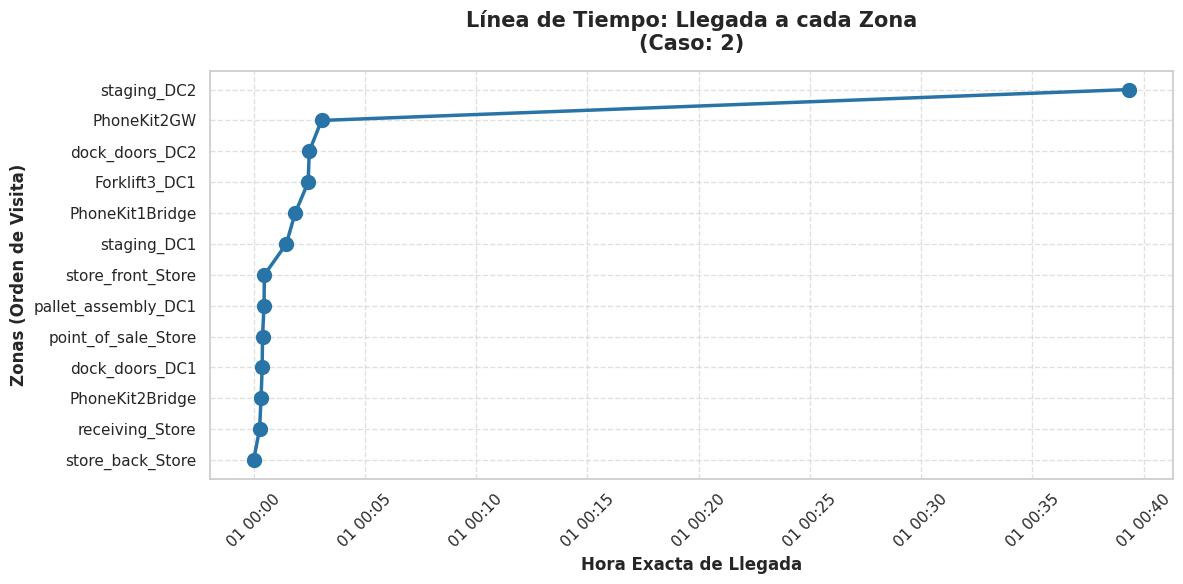

Redujimos el ruido a solo 13 puntos clave (la primera llegada a cada zona).


In [ ]:
import seaborn as sns

df_limpio = df.dropna(subset=['Zone', 'asset_id'])
primer_caso_id = df_limpio['asset_id'].unique()[0]
un_caso = df_limpio[df_limpio['asset_id'] == primer_caso_id].copy()

un_caso = un_caso.sort_values(by='time_est')
viaje_resumido = un_caso.drop_duplicates(subset=['Zone'], keep='first').copy()

orden_real = viaje_resumido['Zone'].values
viaje_resumido['Zone'] = pd.Categorical(viaje_resumido['Zone'], categories=orden_real, ordered=True)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

plt.plot(viaje_resumido['time_est'], viaje_resumido['Zone'],
         marker='o',
         markersize=10,
         linestyle='-',
         linewidth=2.5,
         color='#2874A6')

# 5. Textos y títulos
plt.title(f'Línea de Tiempo: Llegada a cada Zona\n(Caso: {primer_caso_id})', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Hora Exacta de Llegada', fontsize=12, fontweight='bold')
plt.ylabel('Zonas (Orden de Visita)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

print(f"Redujimos el ruido a solo {len(viaje_resumido)} puntos clave (la primera llegada a cada zona).")

### Question 4:

* Visualize how the temperatue changes over time along its journey.  Imagine that this would be included in your presentation to the customer. (Non techical audience) (4 pts)



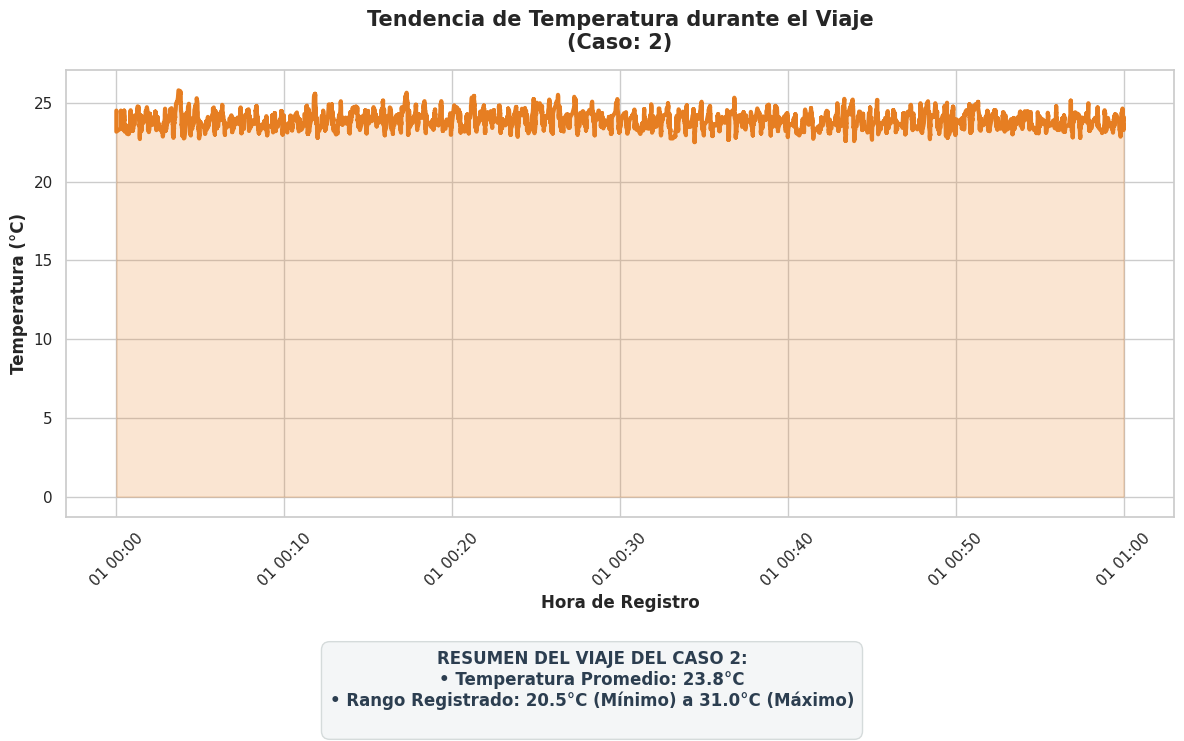

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

col_temp = 'Temperature_C'
df_temp = df.dropna(subset=[col_temp, 'time_est', 'asset_id'])

un_caso_temp = df_temp[df_temp['asset_id'] == primer_caso_id].copy()
un_caso_temp = un_caso_temp.sort_values(by='time_est')

un_caso_temp['Temp_Suavizada'] = un_caso_temp[col_temp].rolling(window=15, min_periods=1).mean()

temp_promedio = un_caso_temp[col_temp].mean()
temp_max = un_caso_temp[col_temp].max()
temp_min = un_caso_temp[col_temp].min()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(un_caso_temp['time_est'], un_caso_temp['Temp_Suavizada'], color='#E67E22', linewidth=3)

ax.fill_between(un_caso_temp['time_est'], un_caso_temp['Temp_Suavizada'], color='#E67E22', alpha=0.2)

# 5. Textos y títulos
ax.set_title(f'Tendencia de Temperatura durante el Viaje\n(Caso: {primer_caso_id})',
          fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Hora de Registro', fontsize=12, fontweight='bold')
ax.set_ylabel('Temperatura (°C)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)

texto_kpis = (
    f"RESUMEN DEL VIAJE DEL CASO {primer_caso_id}:\n"
    f"• Temperatura Promedio: {temp_promedio:.1f}°C\n"
    f"• Rango Registrado: {temp_min:.1f}°C (Mínimo) a {temp_max:.1f}°C (Máximo)\n"
)

plt.figtext(0.5, -0.05, texto_kpis, ha="center", fontsize=12, bbox={"facecolor":"#f4f6f7", "alpha":1, "pad":10, "boxstyle":"round,pad=0.5", "edgecolor": "#d5dbdb"}, fontweight='bold', color='#2c3e50')
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)

plt.show()

### Question 5:
* Visualize the lon lat data on a map to show how the case traveled.  You may incorporate any other additional information to make this more impactful. Imagine that this would be included in your presentation to the customer. (Non techical audience) (5 pts)

**Do not worry if this looks like non-sense on a map.  Ex:  The trip may appear to occur over water or in a forest because this is a toy dataset.**

In [ ]:
import plotly.express as px

df_mapa = df.dropna(subset=['lat', 'lng', 'asset_id', 'time_est'])
un_caso_mapa = df_mapa[df_mapa['asset_id'] == primer_caso_id].copy()
un_caso_mapa = un_caso_mapa.sort_values(by='time_est')

centro_lat = un_caso_mapa['lat'].mean()
centro_lon = un_caso_mapa['lng'].mean()

fig = px.line_mapbox(un_caso_mapa,
                     lat="lat",
                     lon="lng",
                     color_discrete_sequence=["#e74c3c"],
                     hover_name="Zone",
                     hover_data=["time_est", "Temperature_C"],
                     zoom=11,
                     center={"lat": centro_lat, "lon": centro_lon},
                     height=600,
                     title=f"Ruta Geográfica de la Mercancía (Caso: {primer_caso_id})")

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0, "t":50, "l":0, "b":0})

fig.show()

# Part 3: Customer Questions


### Question 6:

The customer wants to understand the efficieny of ther DC operations.
* Based on what you see in the data, (all zones except for STORE), which parts of their operation are most & least "efficient? (10 pts)

In [ ]:
df_dc = df[~df['Zone'].str.contains('Store', case=False, na=False)].copy()
tiempos_estancia = df_dc.groupby(['asset_id', 'Zone'])['time_est'].agg(['min', 'max']).reset_index()

tiempos_estancia['duracion'] = tiempos_estancia['max'] - tiempos_estancia['min']

tiempos_estancia['segundos'] = tiempos_estancia['duracion'].dt.total_seconds()

eficiencia_zonas = tiempos_estancia.groupby('Zone')['segundos'].mean().sort_values()

eficiencia_zonas = eficiencia_zonas[eficiencia_zonas > 0]

print("--- TIEMPO PROMEDIO DE ESTANCIA POR ZONA (En segundos) ---")
print(eficiencia_zonas)
print("ARRIBA (menor tiempo): Más eficientes.")
print("ABAJO (mayor tiempo): Menos eficientes.")

--- TIEMPO PROMEDIO DE ESTANCIA POR ZONA (En segundos) ---
Zone
Forklift1_DC1           638.428571
dock_doors_DC1          859.062500
staging_DC2            1584.142857
PhoneKit1GW            1823.133333
Forklift3_DC1          1980.705882
pallet_assembly_DC1    2158.312500
staging_DC1            2757.500000
dock_doors_DC2         3065.750000
PhoneKit2GW            3386.555556
PhoneKit2Bridge        3553.944444
PhoneKit1Bridge        3565.388889
Name: segundos, dtype: float64
ARRIBA (menor tiempo): Más eficientes.
ABAJO (mayor tiempo): Menos eficientes.


Basado en el tiempo promedio de estancia de la mercancía, la parte más eficiente de la operación es **Forklift1_DC1**, ya que procesa el material en apenas **638 segundos** aproximadamente. Por el contrario, la zona menos eficiente y que representa un cuello de botella es **dock_doors_DC2**, reteniendo la mercancía por **3065 segundos** en promedio.


### Question 7:

The customer wants to understand the stocking efficiency in stores.
* Based on what you see in the data, how quickly did the store unload and stock the merchandise. (5 pts)
* How could this be converted in a KPI that a regional manager could track?  (5 pts)

In [ ]:
df_store = df[df['Zone'].str.contains('Store', case=False, na=False)].copy()

tiempos_tienda = df_store.groupby('asset_id')['time_est'].agg(['min', 'max']).reset_index()

tiempos_tienda['tiempo_total'] = tiempos_tienda['max'] - tiempos_tienda['min']

tiempos_tienda['minutos'] = tiempos_tienda['tiempo_total'].dt.total_seconds() / 60

promedio_minutos = tiempos_tienda['minutos'].mean()

print("--- TIEMPO DE ACOMODO EN TIENDA ---")
print(f"En promedio, la tienda tardó {promedio_minutos:.2f} minutos en descargar y procesar cada caja.")

--- TIEMPO DE ACOMODO EN TIENDA ---
En promedio, la tienda tardó 59.98 minutos en descargar y procesar cada caja.


Basado en el análisis de las lecturas en las zonas de la tienda, el tiempo promedio desde que la mercancía es recibida hasta que termina su ciclo de acomodo es de 59.98 minutos.\
Este dato se puede convertir en un **KPI** llamado ***Dock-to-Shelf Cycle Time***. El Gerente Regional podría rastrear el tiempo promedio mensual que le toma a cada tienda de su región completar este ciclo. Esto le permitiría rankear a sus tiendas, identificar cuáles tienen problemas de personal o cuellos de botella en la descarga y establecer metas de reducción de tiempo para mejorar la disponibilidad del producto para el cliente final.

### Question 8:

Please explain what you would ask for and what you will do with this data, given that you can talk with the following people (no code needed):


**a.** Gerente del Centro de Distribución:

¿Qué pediría?: Pediría los horarios de los turnos de los empleados y el programa de llegada de camiones.

¿Qué se haría con esta información?: Cruzaría esos horarios con los datos de tiempo de estancia. Esto permitiría ver si los "cuellos de botella" ocurren durante los cambios de turno, en las horas pico de llegada de camiones, o si se deben a una falta de personal en zonas específicas como el área de staging.

**b.** Gerente de la Tienda:

¿Qué le pediría?: El plano físico de la tienda, la ubicación de las antenas receptoras y cuántos empleados están asignados a descargar la mercancía cada día.

¿Qué se haría con esta información?: Usaría estos datos junto con el KPI de "Tiempo de Acomodo" para encontrar correlaciones. Por ejemplo, podríamos descubrir si los días que tardan más en descargar coinciden con días de poco personal, o si el diseño del almacén trasero está obligando a los empleados a dar vueltas innecesarias antes de llegar al punto de venta.

## Part 4: Bonus Insights

### Question 8

The customer is open to hearing about additional insights you found in the data above and beyond what they asked for.
* Based on what you can see in the data, are there any other interesting insights that the customer may want to hear about? (Up to 15 bonus points)



**Insight Adicional:** Saturación de Lecturas y Optimización de Sensores.

Al limpiar los datos para las visualizaciones, descubrí que el sistema actual genera una cantidad masiva de datos redundantes. Un solo artículo puede registrar miles de lecturas consecutivas en la misma zona exacta con milisegundos de diferencia, incluso cuando está completamente estático.

**Valor para el cliente:** Aunque la tecnología funciona bien para rastrear la ubicación, este nivel de "ruido" o sobre-lectura no aporta valor logístico adicional y, por el contrario, infla drásticamente los costos de almacenamiento en la nube.

**Recomendación para la fase de despliegue a gran escala:** Sugiero calibrar el software en el origen para que las antenas solo envíen un registro a la base de datos cuando la mercancía cambie de zona, cuando haya un cambio brusco de temperatura, o mediante un "ping" de control cada 15 minutos si está estática. Esto hará que la base de datos sea mucho más ligera, rápida de analizar y económica de mantener a largo plazo.